# Iran war risk and global financial markets in 2026
**Panagiotis Housos · ph2606**

FRE-GY 7871A — NLP and the Investment Process · Assignment 3

Observation cutoff: **16 September 2026**; source-dependent publication lags are recorded below. This notebook applies Rigobon–Sack's covariance-difference method to Iran-related news and financial markets, with NLP measurement and a separate qualitative Truth Social appendix. It contains saved outputs. Follow the README acquisition steps before a fresh execution.

The main finding is an identification limit: the measured oil trend and physical spread are substantial, but the covariance restrictions do not support a stable, precise causal war-risk sensitivity. None of the 32 estimable primary news coefficients is statistically significant. My investment decision is a **10% illustrative allocation to a Treasury bill with about three months remaining**, retaining the diversified core; I would not use these text estimates to initiate a leveraged oil or spread trade.

This is a methodological replication with disclosed public-data proxies, not an exact reconstruction of the proprietary 2003 dataset. Numerical text measures concern physical conflict and economic conditions. The public-official appendix uses neutral qualitative interpretation, not numerical official or policy ratings.

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Execute this notebook from the repository root.')
sys.path.insert(0, str(ROOT))
OUT = ROOT / 'outputs'
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
pd.options.display.float_format = '{:,.4f}'.format
required = ['market_changes.csv','market_levels.csv','news_documents.csv','social_candidates.csv','gpr_benchmark.csv']
missing = [p for p in required if not (ROOT/'data/processed'/p).exists()]
assert not missing, f'Run the README acquisition steps first; missing: {missing}'
print('Input files present. No live data are silently substituted during notebook execution.')

Input files present. No live data are silently substituted during notebook execution.


## 1. Recompute the text features and econometrics
The code below rebuilds the text measures from cached bodies, checks all social candidates against the raw snapshot, and regenerates the econometric tables and figures. Random seeds and bootstrap counts are explicit. The paired bootstrap assumes independence between different pairs; it is not a block-bootstrap or formal rank test.

In [2]:
from src.text_features import build as build_text
from src.social_audit import main as audit_social
from src.analysis import run, OUTCOMES, LABELS, UNITS
from src.figures import build as build_figures
features, news_daily = build_text()
audit_social()
diagnostics = run(bootstrap=1999)
build_figures()
for name, digest in diagnostics['input_sha256'].items():
    assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest() == digest
print('Recomputed analysis and verified input hashes.')

{
  "eligible_news_documents": 1029,
  "within_cutoff_documents": 1025,
  "war_relevant_documents": 917,
  "numeric_text_eligible": 218,
  "modified_after_cutoff": 4,
  "mapped_effective_date": 1025,
  "scoring_target": "Unquoted physical conflict/economic context after paragraph-level official-subject, policy and attribution exclusions, plus sentence-level personal-anaphora exclusions. Attention counts independently retain all relevant articles.",
  "limits": "Conservative heuristic exclusions can omit factual reporting and cannot guarantee semantic separation; no independent labeled accuracy; financial LM vocabulary transferred to news; current revised text. Absence of eligible text yields a missing value, not neutrality.",
  "idf": "Full eligible news corpus, retrospective; no prediction claim."
}


{
  "candidate_rows_audited": 403,
  "candidate_ids_match_independent_raw_retrieval": true,
  "all_text_and_local_dates_match_raw_snapshot": true,
  "candidate_csv_sha256": "addb2f87477ebccf8867dce3916e417bc8c09420beb75c800968872ac26d2781",
  "archive_sha256": "6481b8a27413428bcf09c48c30ef48b3d807c44c2176917a7be0a8a1f0d6b4a1",
  "source_form_counts": {
    "Text without URL or explicit attribution prefix": 258,
    "Text plus URL": 95,
    "Explicit RT marker": 43,
    "Explicit attribution prefix": 4,
    "URL only": 3
  },
  "relevance_match_location_counts": {
    "Body": 327,
    "Body and URL": 65,
    "URL only": 11
  },
  "explicit_repost_marker_records": 43,
  "explicit_self_repost_prefix_records": 31,
  "explicit_attribution_prefix_records": 4,
  "url_only_records": 3,
  "records_with_urls": 109,
  "records_with_unreviewed_media": 16,
  "empty_text_records_with_media_in_full_2026_window": 1894,
  "candidate_records_with_identical_text_other_id": 26,
  "unique_candidate_texts":

{
  "created_utc": "2026-09-18T16:17:43.568852+00:00",
  "cutoff": "2026-09-16",
  "event_records": 25,
  "unique_event_dates": 24,
  "matched_pairs": 24,
  "nlp_pairs": 41,
  "primary_news_tests": 32,
  "primary_news_unadjusted_p_lt_05": 0,
  "primary_news_q_lt_05": 0,
  "bootstrap_repetitions": 1999,
  "weak_two_year_pairs": 13,
  "two_year_estimates": 17,
  "benchmark_n": 76,
  "rank_one_residual": 0.5006628468234156
}
               y  n_pairs  var_ratio  d_pooled_scenario  weak_identification
        wti_spot       24     1.7830            -8.7440                 True
      brent_spot       20     2.3651             2.1513                False
brent_wti_spread       20     2.3651             3.2615                False
           sp500       24     1.7830             1.5689                 True
          nasdaq       24     1.7830             1.0884                 True
             efa       24     1.7830             1.4084                 True
             eem       24     1.783

Recomputed analysis and verified input hashes.


## 2. Sample, source vintages and market definitions
The Guardian Iran-tag archive is a single English-language outlet. News/analysis in specified news sections is retained; live blogs, multimedia and opinion sections are excluded. Raw body snapshots may have been edited. The later of publication and last-modified clocks is used; bodies revised beyond the cutoff are excluded from both timing conventions and IDF fitting. Four download failures remain in the audit.

The sample starts in January, but collection is not a claim to capture every global news story. A minimum of 80 extracted body words is required; exact duplicate bodies would be excluded. Each source URL, clock and hash is retained locally. No raw articles or full social-post dataset is committed.

Prices use $100\Delta\log P$; yields, breakevens and credit spreads use basis-point changes. The Brent–WTI spot spread uses dollar changes. Every joint model requires matching current **and preceding** observation dates. No forward filling occurs. OAS can contain month-end weekend accrual observations; holiday/nontrading intervals that do not align with the anchor are excluded.

Original off-the-run yield curves become constant-maturity Treasury yields; original credit spreads become OAS; original gold becomes GLD returns. The original 12-month oil contract is not available in this public-data panel: spot and separately labeled rolling futures are proxies. EFA/EEM combine foreign equity and exchange-rate exposure in USD. DXY and the broad dollar have different baskets. The original on-the-run liquidity premium is not replicated.

In [3]:
manifest = json.loads((ROOT/'data/raw/news/manifest.json').read_text())
text_audit = json.loads((OUT/'text_diagnostics.json').read_text())
exclusions = manifest['exclusions']
download_failures = sum(count for reason, count in exclusions.items()
                        if reason.startswith('download/parse failure:'))
display(pd.DataFrame([{'step':'Discovered unique 2026 URLs','count':manifest['discovered_unique_2026_urls']},
 {'step':'Live blog or multimedia','count':exclusions.get('live blog or multimedia',0)},
 {'step':'Non-news section','count':exclusions.get('non-news section',0)},
 {'step':'Download/parse failures','count':download_failures},
 {'step':'Extracted news documents','count':text_audit['eligible_news_documents']},
 {'step':'Revision beyond cutoff','count':text_audit['modified_after_cutoff']},
 {'step':'Within-cutoff documents','count':text_audit['within_cutoff_documents']},
 {'step':'War-relevant documents','count':text_audit['war_relevant_documents']},
 {'step':'At least 20 eligible physical-context tokens','count':text_audit['numeric_text_eligible']}]))
market_manifest = json.loads((ROOT/'data/raw/market/manifest.json').read_text())
display(pd.DataFrame(market_manifest['series'])[['series','provider','first','last','observations_2026','source_url']])
assert not market_manifest['failures']

,step,count
0,Discovered unique 2026 URLs,1893
1,Live blog or multimedia,444
2,Non-news section,416
3,Download/parse failures,4
4,Extracted news documents,1029
5,Revision beyond cutoff,4
6,Within-cutoff documents,1025
7,War-relevant documents,917
8,At least 20 eligible physical-context tokens,218


,series,provider,first,last,observations_2026,source_url
0,DCOILWTICO,FRED,2025-12-15,2026-09-15,176,https://fred.stlouisfed.org/series/DCOILWTICO
1,DCOILBRENTEU,FRED,2025-12-15,2026-09-15,178,https://fred.stlouisfed.org/series/DCOILBRENTEU
2,DGS2,FRED,2025-12-15,2026-09-15,177,https://fred.stlouisfed.org/series/DGS2
3,DGS10,FRED,2025-12-15,2026-09-15,177,https://fred.stlouisfed.org/series/DGS10
4,DGS3MO,FRED,2025-12-15,2026-09-15,177,https://fred.stlouisfed.org/series/DGS3MO
5,T10YIE,FRED,2025-12-15,2026-09-16,178,https://fred.stlouisfed.org/series/T10YIE
6,BAMLC0A4CBBB,FRED,2025-12-15,2026-09-16,187,https://fred.stlouisfed.org/series/BAMLC0A4CBBB
7,BAMLH0A0HYM2,FRED,2025-12-15,2026-09-16,187,https://fred.stlouisfed.org/series/BAMLH0A0HYM2
8,DTWEXBGS,FRED,2025-12-15,2026-09-11,175,https://fred.stlouisfed.org/series/DTWEXBGS
9,CL=F,Yahoo Finance,2025-12-15,2026-09-16,177,https://finance.yahoo.com/quote/CL%3DF/history/


## 3. WTI, Brent and the spread
$S_t=Brent^{spot}_t-WTI^{spot}_t$ is measured in USD per barrel. A positive value means Brent is more expensive. Geography, quality, transport, inventories and refining demand can affect it; it is not a pure war premium. Spot and rolling-futures observations must not be mixed. Even the two rolling-futures quotes can represent different delivery months ([EIA](https://www.eia.gov/todayinenergy/detail.php?id=67424)).

The spot spread rises from $4.77 to $23.78. Endpoint price increases are 87.07% for WTI and 111.04% for Brent (simple changes); the econometric return unit is instead log percentage points. On September 15, the rolling-futures quote difference is about $2.92, a different instrument comparison.

**Investment implication.** Do not initiate a spread convergence trade merely because the spot differential is wide. A tradable spread requires matched maturities, basis-risk analysis and a separately justified entry rule.

,variable,first_date,last_date,first,last,change,unit,n,daily_sd
0,wti_spot,2026-01-02,2026-09-15,57.2100,107.0200,62.6287,log_percent,176,3.9535
1,brent_spot,2026-01-02,2026-09-15,61.9800,130.8000,74.6858,log_percent,178,4.3692
2,wti_futures,2026-01-02,2026-09-16,57.3200,102.4300,58.0530,log_percent,177,4.0236
3,brent_futures,2026-01-02,2026-09-16,60.7500,105.8300,55.5067,log_percent,177,3.9816
4,sp500,2026-01-02,2026-09-16,"6,858.4702","7,551.8101",9.6303,log_percent,177,0.8350
5,nasdaq,2026-01-02,2026-09-16,"23,235.6309","25,978.4297",11.1580,log_percent,177,1.2021
6,vix,2026-01-02,2026-09-16,14.5100,17.7100,19.9291,log_percent,179,7.6485
7,dollar,2026-01-02,2026-09-16,98.4200,100.3100,1.9021,log_percent,177,0.3460
8,efa,2026-01-02,2026-09-16,95.5283,105.0200,9.4728,log_percent,177,1.0960
9,eem,2026-01-02,2026-09-16,55.9492,65.7200,16.0959,log_percent,177,1.7961


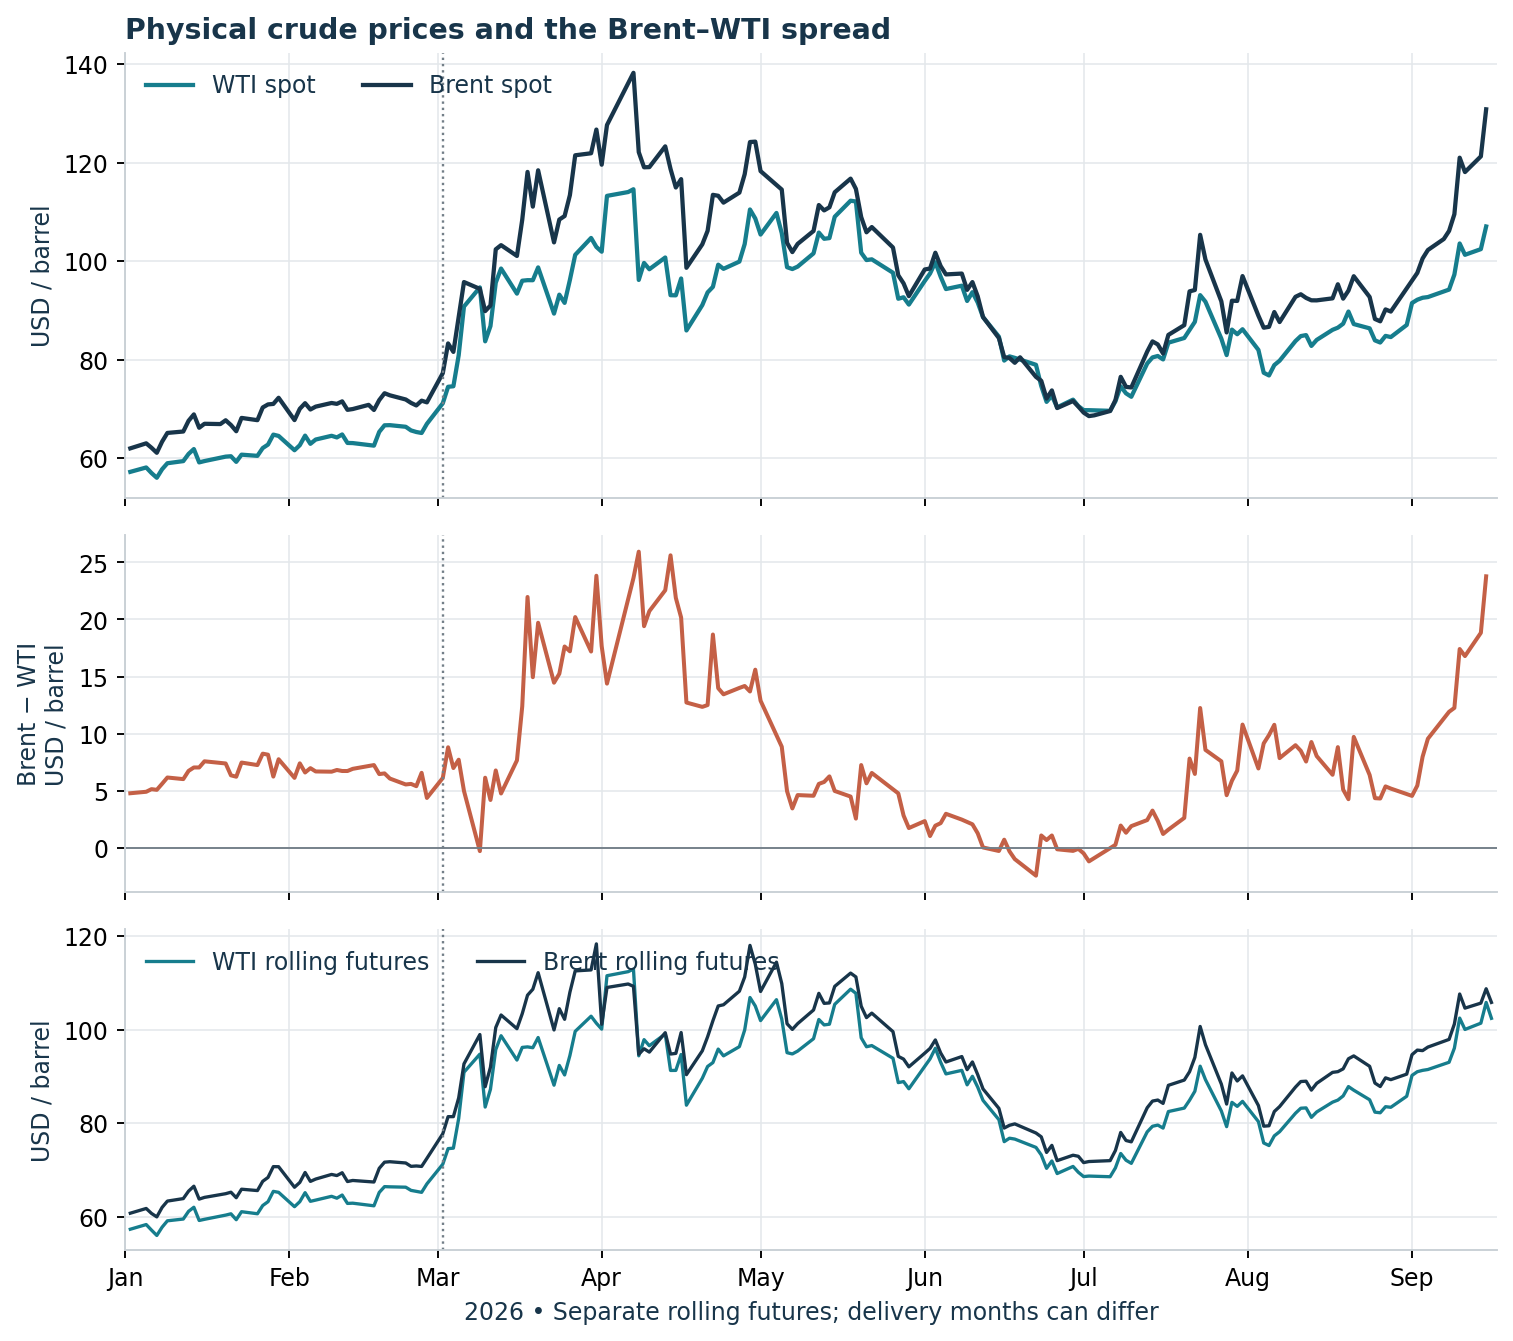

In [4]:
summary = pd.read_csv(OUT/'market_summary.csv')
display(summary[['variable','first_date','last_date','first','last','change','unit','n','daily_sd']])
display(Image(filename=str(OUT/'figure1_oil.png')))

## 4. Global assets and yield trends
Equities finish above the first January observation despite intervening drawdowns. The two-year yield rises 120 bp and the ten-year 81 bp, narrowing 10s2s from 72 to 33 bp: endpoint bear flattening. Those full-period changes include other news and do not identify the war contribution. An oil-supply/inflation shock may raise yields while growth concerns lower them; the 2003 sign pattern cannot be imposed on Iran in 2026.

**Investment implication.** Keep diversification and avoid treating long-duration Treasuries as an automatic hedge against an inflationary supply interruption. The defensive allocation uses short bills.

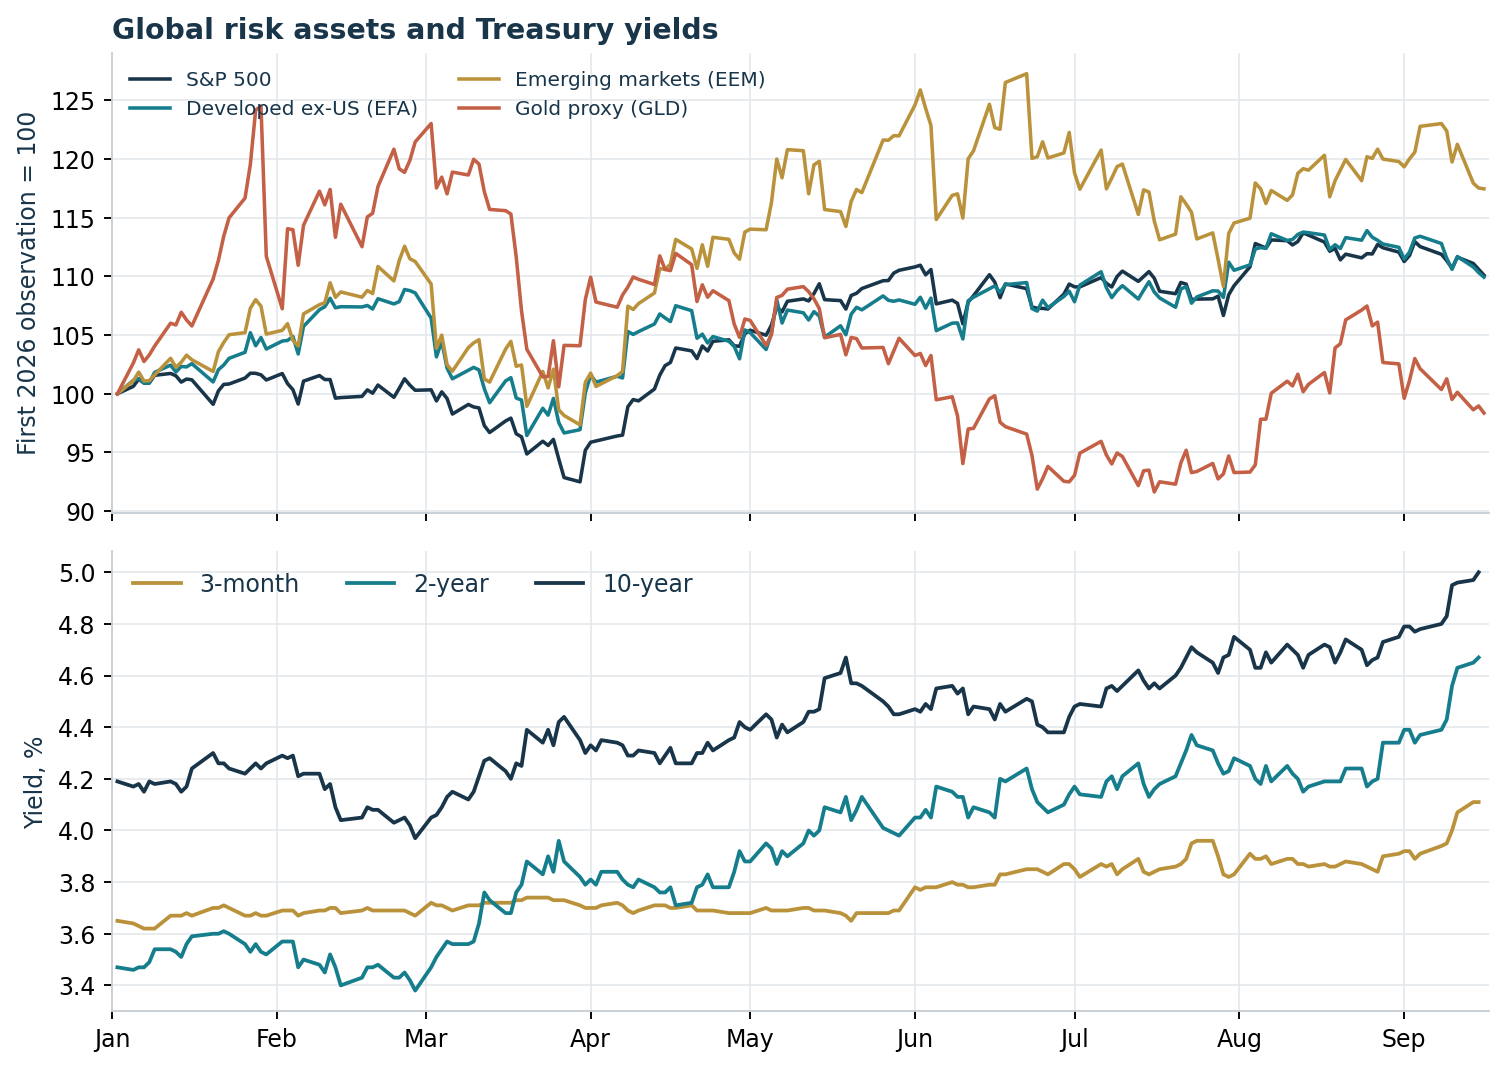

In [5]:
display(Image(filename=str(OUT/'figure2_markets.png')))

## 5. News attention and sentiment around physical conflict
Relevance requires a conflict/energy context and Iran-related entity in the headline, or at least two body sentences with both contexts. The literal rules are in `src/text_features.py`. They have no independent human-labeled accuracy estimate.

Attention is $A_t=\log(1+n_t/d_t)$, where $n_t$ is the number of relevant documents in the session interval and $d_t$ its calendar-day length. It measures retrieved coverage, not war probability. Relevance and attention use the original text independently of the lexical exclusions. The numerical sample excludes whole paragraphs containing official/policy subjects or attribution cues, then removes quoted spans before sentence splitting. Retained sentences require a physical-context term and exclude personal/institutional pronouns, rhetorical questions and quotation-bearing fragments. These conservative rules omit much factual reporting too; they cannot guarantee semantic separation. Official statements and policy assessments are not numerically rated.

For category $c$, the token-weighted daily measure is $L_{ct}=100\sum_j C_{cj}/\sum_j N_j$, using only documents with at least 20 eligible tokens. No eligible text gives a missing measure, not zero or neutral sentiment. The verified March 2026 Loughran–McDonald release has 2,345 active negative and 297 uncertainty words (positive year flags only). Tokens are alphabetic strings of at least two characters. The financial dictionary is imperfect for war news and misses contextual negation and target differences.

Assignment 1's exact supplement uses $\sum_{w\in c}(1+\log tf_{wj})\log(N/df_w)/(1+\log a_j)$, where $a_j$ is tokens divided by distinct tokens in document $j$. IDF is fitted to the eligible full corpus; these retrospective weights are not an out-of-sample signal. Literal threat and action patterns are additional context counts. The diplomacy pattern remains documented but its terms are excluded by the numerical policy filter. No numerical political evaluations are produced.

,rule,literal_pattern
0,Conflict/energy,\b(?:war|wars|military|missiles?|drones?|bomb\...
1,Physical context,\b(?:missiles?|drones?|bomb\w*|airstrikes?|str...
2,Iran entities,\b(?:iran\w*|tehran|hormuz|persian gulf|kharg)\b
3,Threat words,\b(?:risk\w*|threat\w*|fear\w*|warn\w*|could|m...
4,Action words,\b(?:attacked|struck|killed|bombed|launched|de...
5,Diplomacy words,\b(?:ceasefire|talks|negotiat\w*|truce|peace|a...
6,Excluded subjects/policies,\b(?:trump|biden|hegseth|netanyahu|khamenei|pe...
7,Excluded attribution,\b(?:say|says|said|saying|tell|tells|told|stat...
8,Excluded anaphora,\b(?:he|him|his|she|her|hers|we|us|our|ours|i|...


,date,articles,war_articles,sessions,attention,negative_pct,uncertainty_pct,threat_pct,act_pct
0,2026-01,75,44,20,1.7208,2.4590,0.0000,0.0000,16.6667
1,2026-02,23,13,19,0.5351,NaN,NaN,NaN,NaN
2,2026-03,393,370,22,11.6364,2.0827,0.8577,7.7036,18.4745
3,2026-04,166,156,21,5.5833,3.7798,0.7225,6.7424,17.7273
4,2026-05,93,81,20,2.9583,2.1002,0.9345,3.4286,10.8333
5,2026-06,118,107,21,3.7817,2.8946,0.6031,3.1111,13.0000
6,2026-07,84,79,22,2.8106,2.0084,0.6734,3.7037,11.1111
7,2026-08,44,39,21,1.2540,1.1640,0.8658,0.0000,26.1905
8,2026-09,29,28,11,1.9621,2.1303,0.6859,5.5556,27.7778


,n_words,negative_pct,uncertainty_pct,negative_tfidf,uncertainty_tfidf
count,"1,025.0000",282.0000,282.0000,282.0000,282.0000
mean,11.6732,2.5418,0.5743,5.1131,1.2613
std,25.3610,3.0633,1.4289,6.2296,3.2557
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,1.7630,0.0000,4.0433,0.0000
75%,15.0000,4.3478,0.0000,8.6311,0.0000
max,188.0000,15.0000,9.0909,30.2698,22.4051


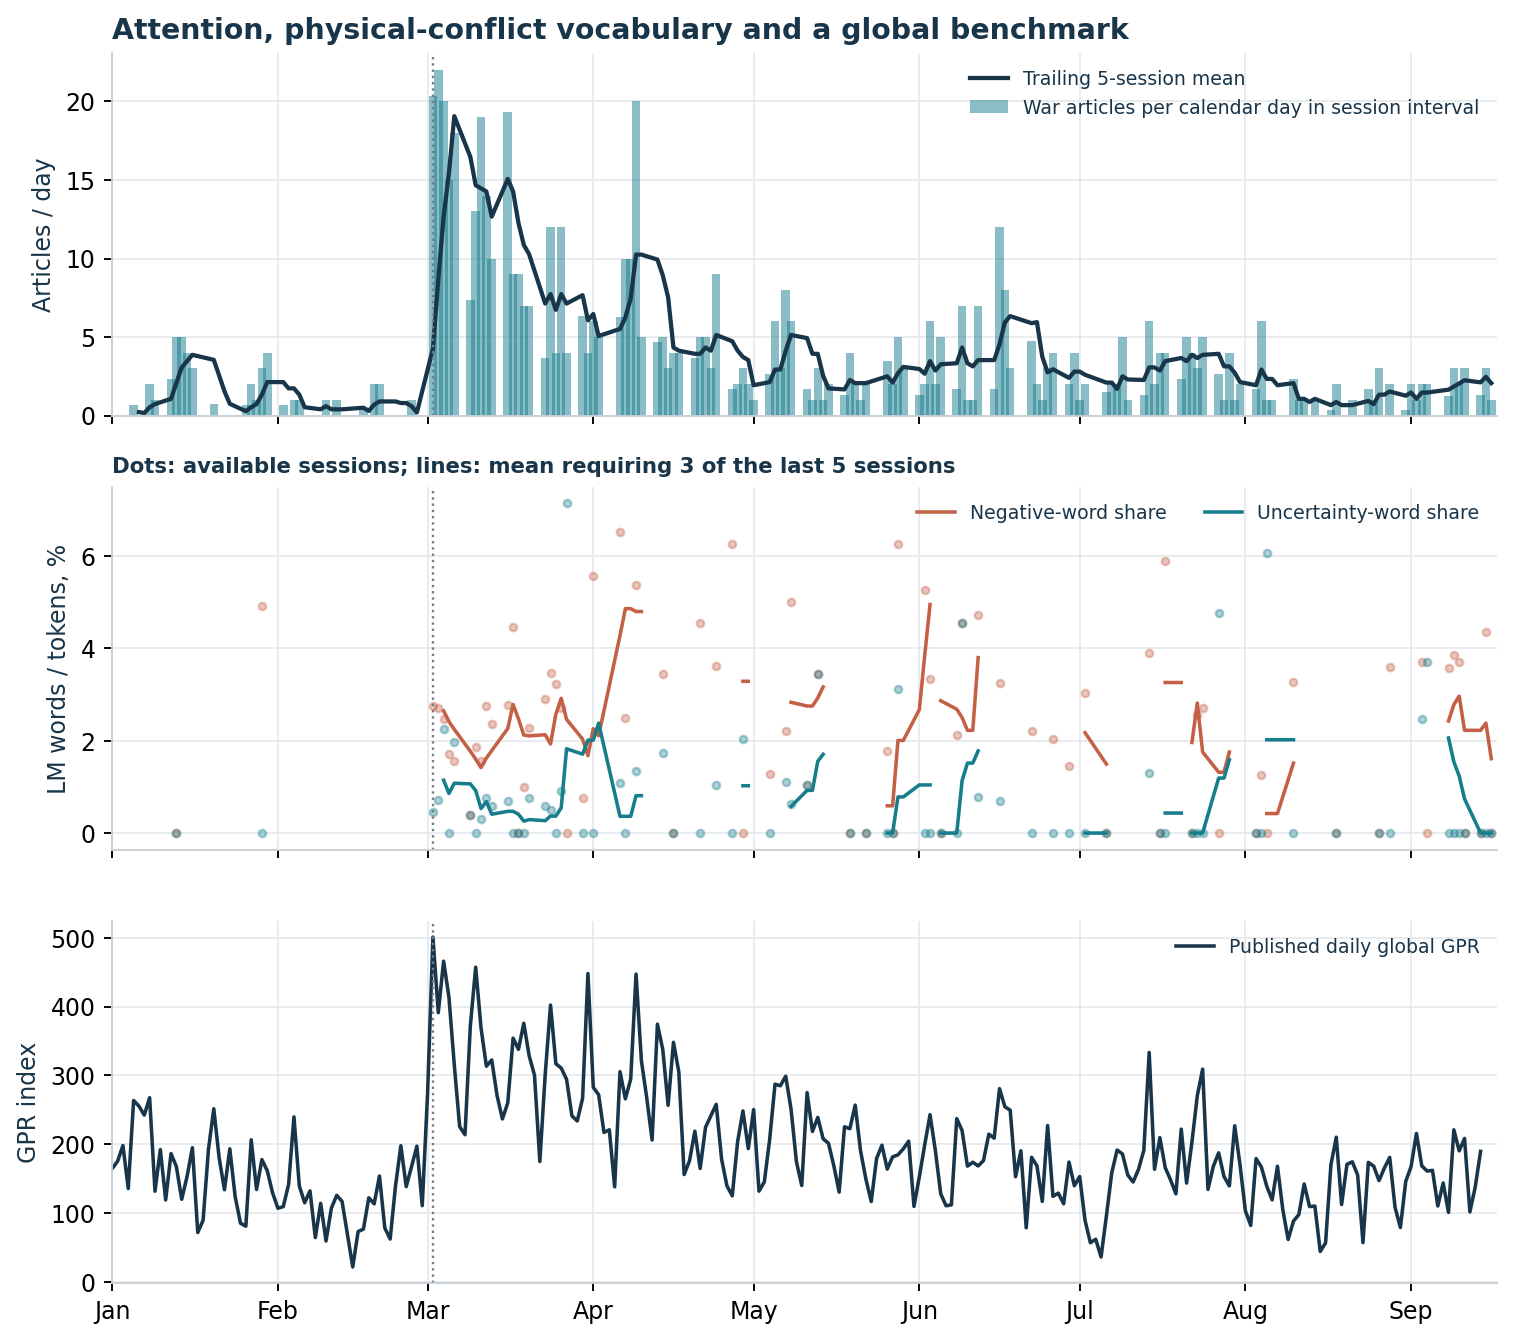

In [6]:
from src.text_features import CONFLICT, PHYSICAL, IRAN, THREAT, ACT, DIPLOMACY, POLITICAL, ATTRIBUTION, ANAPHORA
display(pd.DataFrame({'rule':['Conflict/energy','Physical context','Iran entities','Threat words','Action words','Diplomacy words','Excluded subjects/policies','Excluded attribution','Excluded anaphora'],
 'literal_pattern':[x.pattern for x in [CONFLICT,PHYSICAL,IRAN,THREAT,ACT,DIPLOMACY,POLITICAL,ATTRIBUTION,ANAPHORA]]}))
display(pd.read_csv(OUT/'news_monthly.csv'))
display(features[['n_words','negative_pct','uncertainty_pct','negative_tfidf','uncertainty_tfidf']].describe())
display(Image(filename=str(OUT/'figure3_news.png')))

Attention covers 917 relevant articles across 177 sessions. Only 218 articles supply enough eligible lexical text, spanning 78 sessions. Attention rises sharply around the outbreak and later falls. The negative-vocabulary trend is -0.119 percentage points per month (p=0.180); its post-March level difference is also nonsignificant (p=0.677). Uncertainty vocabulary has a +0.874 percentage-point step (q=0.006), but no detectable time trend (p=0.722). These describe a selected, sparse text sample, not changing public opinion or an official's attitude.

Lower news activity does not establish lower physical risk. The global GPR benchmark includes other countries and is a revised newspaper index, not a daily real-time Iran probability. Its correlation with log attention is 0.765, versus 0.083 for negative-word share, on 76 common dates.

**Investment implication.** Use attention to trigger review of exposure and source developments; do not remove an energy hedge only because vocabulary or coverage becomes less negative.

In [7]:
display(pd.read_csv(OUT/'trend_tests.csv'))
display(pd.read_csv(OUT/'benchmark_correlations.csv',index_col=0))
display(pd.read_csv(OUT/'common_words.csv').head(30))

,feature,term,coefficient,p_value,ci_low,ci_high,n,q_value
0,log_attention,time_months,-0.2551,0.0000,-0.3303,-0.1799,177,0.0000
1,log_attention,active_conflict,1.9387,0.0000,1.5176,2.3597,177,0.0000
2,negative_pct,time_months,-0.1188,0.1799,-0.2937,0.0561,78,0.2998
3,negative_pct,active_conflict,0.3646,0.6771,-1.3729,2.1021,78,0.7730
4,uncertainty_pct,time_months,-0.0237,0.7219,-0.1556,0.1083,78,0.7730
5,uncertainty_pct,active_conflict,0.8739,0.0024,0.3207,1.4271,78,0.0059
6,threat_pct,time_months,-0.9049,0.0654,-1.8689,0.0591,78,0.1308
7,threat_pct,active_conflict,8.7513,0.0000,4.9784,12.5241,78,0.0001
8,act_pct,time_months,0.6905,0.5960,-1.8929,3.2739,78,0.7730
9,act_pct,active_conflict,-1.9589,0.7730,-15.4391,11.5214,78,0.7730


,log_attention,negative_pct,GPRD,GPRD_ACT,GPRD_THREAT
log_attention,1.0000,0.1965,0.7648,0.7016,0.6786
negative_pct,0.1965,1.0000,0.0832,0.0354,0.1647
GPRD,0.7648,0.0832,1.0000,0.9212,0.9034
GPRD_ACT,0.7016,0.0354,0.9212,1.0000,0.7108
GPRD_THREAT,0.6786,0.1647,0.9034,0.7108,1.0000


,word,count
0,THE,950
1,OF,476
2,IN,334
3,AND,326
4,TO,270
5,OIL,211
6,ON,201
7,STRAIT,105
8,IRAN,104
9,AS,95


## 6. Identification and event design
Rigobon–Sack's reduced form is $\Delta X_t=d w_t+u_t$. If only the orthogonal war-factor variance changes and loadings/nuisance covariance stay stable, $\Delta\Omega=\Omega_H-\Omega_L=\delta dd'$ with $\delta>0$: a positive rank-one matrix. Heteroskedasticity-robust OLS standard errors alone do not identify a structural effect.

With the two-year-yield response normalized to one, let $a=\Delta Var(x)$, $b=\Delta Cov(x,y)$ and $c=\Delta Var(y)$. The two estimates are $d_1=b/a$ and $d_2=c/b$. Pooled IV instruments $x$ with $s x$ and $s y$, where $s=+1$ on H and −1 on L. Centered moments use within-regime demeaning and denominator n consistently; original zero-mean second moments are also estimated.

The retrospective source calendar has 25 developments on 24 sessions, selected without return filtering. Controls are unused, within 35 calendar days, in the same pre-/post-February-28 period, not event or adjacent sessions, and at/below their own month's median attention. Same-month then closest dates are preferred. Two controls have the same attention as H and two have more; labels hypothesize a variance shift rather than demonstrate it.

Weekend news maps to the next equity session. April 7's 18:32 EDT ceasefire maps to April 8. Uncertain source clocks are shifted one session in a robustness check. Body features use the first observed session with its 15:00 ET cutoff at or after the effective timestamp. Daily market closes are not fully synchronous.

In [8]:
events = pd.read_csv(OUT/'event_calendar.csv')
matching = pd.read_csv(OUT/'matching_audit.csv')
display(events[['event_date','market_date','description','timing_uncertain','source_url']])
display(matching)
print('Events:', diagnostics['event_records'], 'Distinct sessions:', diagnostics['unique_event_dates'],
      'Matched pairs:', diagnostics['matched_pairs'], 'Alternative NLP pairs:', diagnostics['nlp_pairs'])

,event_date,market_date,description,timing_uncertain,source_url
0,2026-01-14,2026-01-14,Some Al Udeid personnel advised to leave Qatar,True,https://www.investing.com/news/commodities-new...
1,2026-01-26,2026-01-26,USS Abraham Lincoln and accompanying warships ...,True,https://apnews.com/article/58e6da912f9167df94f...
2,2026-02-06,2026-02-06,Iran and United States hold indirect talks in ...,True,https://apnews.com/article/32d621b98f7a3a68831...
3,2026-02-17,2026-02-17,United States and Iran hold Geneva nuclear talks,True,https://www.investing.com/news/commodities-new...
4,2026-02-26,2026-02-26,Geneva talks end with further negotiations ann...,True,https://wtop.com/world/2026/02/omans-foreign-m...
5,2026-02-28,2026-03-02,United States and Israel begin attacks on Iran,False,https://apnews.com/article/04da58cbae991183f8b...
6,2026-03-18,2026-03-18,South Pars facilities attacked; Iran attacks G...,True,https://www.investing.com/news/world-news/iran...
7,2026-04-07,2026-04-08,United States and Iran announce two-week cease...,False,https://www.upi.com/Top_News/US/2026/04/07/Ira...
8,2026-04-12,2026-04-13,Islamabad talks end without agreement,False,https://apnews.com/article/04da58cbae991183f8b...
9,2026-04-13,2026-04-13,United States begins blockade of Iranian ports,True,https://apnews.com/article/04da58cbae991183f8b...


,pair_id,high_date,low_date,status,high_attention,low_attention,gap_calendar_days
0,0,2026-01-14,2026-01-09,matched,5.0000,1.0000,5
1,1,2026-01-26,2026-01-28,matched,0.6667,1.0000,2
2,2,2026-02-06,2026-02-03,matched,0.0000,0.0000,3
3,3,2026-02-17,2026-02-11,matched,0.5000,0.0000,6
4,4,2026-02-26,2026-02-24,matched,1.0000,0.0000,2
5,5,2026-03-02,2026-03-09,matched,20.3333,7.3333,7
6,6,2026-03-18,2026-03-20,matched,9.0000,7.0000,2
7,7,2026-04-08,2026-04-15,matched,10.0000,3.0000,7
8,8,2026-04-13,2026-04-27,matched,4.6667,1.6667,14
9,9,2026-04-17,2026-04-28,matched,4.0000,2.0000,11


Events: 25 Distinct sessions: 24 Matched pairs: 24 Alternative NLP pairs: 41


## 7. Covariance-difference results
The anchor is in basis points, so multiply every response coefficient by **−25**, not −0.25, to reproduce the paper's 25-bp-yield-decline normalization. Price outcome units remain log percentage points; the oil spread is USD/barrel; yield/OAS outcomes are bp. This normalization does not establish which direction means increased 2026 Iran risk.

The bootstrap resamples matched pairs together (1,999 draws). If the anchor variance difference is nonpositive or its bootstrap interval crosses zero, reported coefficient intervals are withheld; raw estimates and raw bootstrap draws' intervals remain diagnostics. This is not a formal weak-IV test. Four unflagged outcomes use smaller 20-pair samples, so apparent identification differences also reflect sample composition.

,y,n_pairs,var_ratio,delta_var_x,delta_var_x_ci_low,delta_var_x_ci_high,weak_identification
0,wti_spot,24,1.7830,14.1250,-2.8391,30.3391,True
1,brent_spot,20,2.3651,20.4600,2.1002,36.9732,False
2,brent_wti_spread,20,2.3651,20.4600,3.2774,39.5835,False
3,sp500,24,1.7830,14.1250,-2.2499,31.1694,True
4,nasdaq,24,1.7830,14.1250,-2.2548,31.1458,True
5,efa,24,1.7830,14.1250,-2.6000,30.2569,True
6,eem,24,1.7830,14.1250,-2.7225,31.2808,True
7,vix,23,1.7280,13.7013,-4.0813,31.8811,True
8,gold_gld,24,1.7830,14.1250,-2.1377,30.8352,True
9,dollar,24,1.7830,14.1250,-2.4290,30.3708,True


,y,d_reference_scenario,d_outcome_scenario,d_pooled_scenario,d_pooled_scenario_ci_low,d_pooled_scenario_ci_high,weak_identification
0,wti_spot,-9.4595,-93.9686,-8.7440,NaN,NaN,True
1,brent_spot,-7.5506,-111.4360,2.1513,-93.5130,32.4906,False
2,brent_wti_spread,-0.3910,-435.3945,3.2615,-38.1070,15.9919,False
3,sp500,1.7509,5.7187,1.5689,NaN,NaN,True
4,nasdaq,1.1401,2.0995,1.0884,NaN,NaN,True
5,efa,1.5101,2.6085,1.4084,NaN,NaN,True
6,eem,0.9180,6.1882,0.6838,NaN,NaN,True
7,vix,-8.0915,28.3788,-9.8781,NaN,NaN,True
8,gold_gld,4.4188,-23.8988,4.4859,NaN,NaN,True
9,dollar,-1.4969,-0.6475,-1.1129,NaN,NaN,True


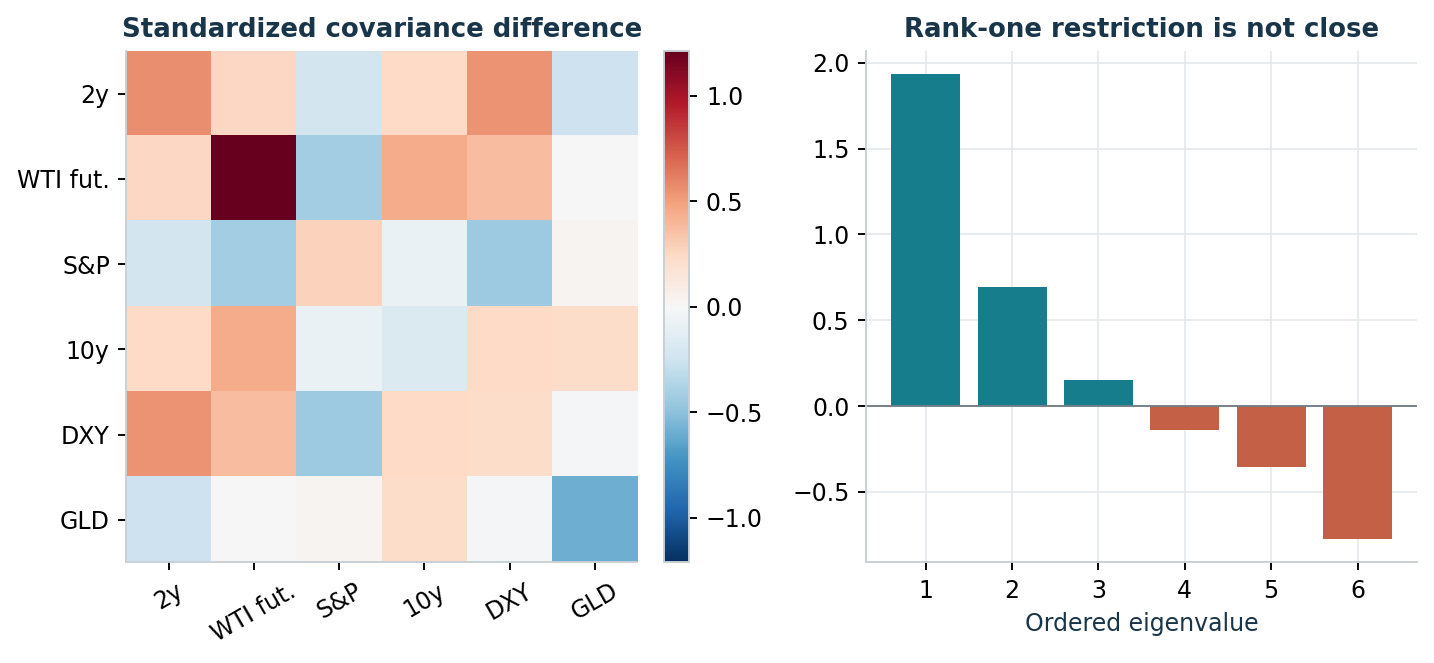

,eigenvalue
0,1.9324
1,0.6936
2,0.1492
3,-0.1389
4,-0.3540
5,-0.7753


In [9]:
het = pd.read_csv(OUT/'heteroskedasticity.csv')
display(het[['y','n_pairs','var_ratio','delta_var_x','delta_var_x_ci_low','delta_var_x_ci_high','weak_identification']])
display(het[['y','d_reference_scenario','d_outcome_scenario','d_pooled_scenario',
             'd_pooled_scenario_ci_low','d_pooled_scenario_ci_high','weak_identification']])
display(Image(filename=str(OUT/'figure4_identification.png')))
display(pd.DataFrame({'eigenvalue':json.loads((OUT/'rank_diagnostics.json').read_text())['eigenvalues']}))

Thirteen of 17 outcomes fail the conservative anchor-variance diagnostic. The six-market rank-one residual is 0.501, with several nonzero/negative eigenvalues; it is a descriptive diagnostic, not a formal rejection p-value. Moment estimates disagree substantially. Even unflagged pairwise estimates have wide intervals or poor moment agreement. No table is treated as a reliable causal hedge ratio.

The supplied 2003 Table 2 pooled responses under the same yield normalization were −26 bp (10y), −3.76% (S&P), +5 bp (BBB), +34 bp (HY), −0.44% (broad dollar) and +$0.77 (12-month oil futures). Proxies and units differ; those signs are not imposed on 2026.

**Investment implication.** Do not translate the raw normalized coefficients into a leveraged cross-asset portfolio. A yield decline need not represent the same economic shock in the two conflicts.

In [10]:
oil = pd.read_csv(OUT/'oil_anchor.csv')
display(oil[['y','n_pairs','d_pooled_scenario','weak_identification']])
print('Oil normalization: +10% simple WTI-futures increase = 100*log(1.10) log points; all comparisons fail the anchor diagnostic.')

,y,n_pairs,d_pooled_scenario,weak_identification
0,wti_spot,24,9.5479,True
1,brent_spot,20,9.7711,True
2,brent_wti_spread,20,2.0532,True
3,sp500,24,-0.6872,True
4,nasdaq,24,-0.6088,True
5,efa,24,-1.4773,True
6,eem,24,-1.8128,True
7,vix,23,6.3864,True
8,gold_gld,24,-0.4877,True
9,dollar,24,0.2120,True


Oil normalization: +10% simple WTI-futures increase = 100*log(1.10) log points; all comparisons fail the anchor diagnostic.


## 8. Robustness and variance attribution
Robustness covers original uncentered second moments, removal of entire pairs touching FOMC decisions, shifting uncertain event dates, within-month high-attention regimes, January–May/June–September subsamples and leave-one-pair-out influence. A changing sign is evidence against relying on one convenient specification. The NLP regime rule selects on text, but article count need not equal shock variance.

The original variance calculation is $q_j=d_j^2a$; H share is $q_j/Var_H(y)$ and the full-period quantity is $n_Hq_j/[T Var_{all}(y)]$. The denominator uses the actual all-period aligned sample, not just selected controls. The cumulative-variance interpretation additionally needs serial independence. Values below are conditional algebraic diagnostics, **not established causal lower bounds**. They are not clipped into [0,100].

In [11]:
robust = pd.read_csv(OUT/'heteroskedasticity_robustness.csv')
display(robust[robust.y.isin(['wti_spot','brent_spot','brent_wti_spread','sp500','ten_year'])][
 ['specification','y','n_pairs','delta_var_x','d_pooled_scenario','weak_identification']])
display(het[['y','var_y_low','var_y_high','incremental_variance','high_variance_share','all_variance_share','variance_attribution_caution']])
influence = pd.read_csv(OUT/'event_influence.csv')
display(influence.groupby('outcome').d_pooled.agg(['min','median','max']))

,specification,y,n_pairs,delta_var_x,d_pooled_scenario,weak_identification
0,uncentered_second_moments,wti_spot,24,16.0833,8.9696,True
1,uncentered_second_moments,brent_spot,20,19.8000,3.9830,True
2,uncentered_second_moments,brent_wti_spread,20,19.8000,-0.6910,True
3,uncentered_second_moments,sp500,24,16.0833,0.8835,True
11,uncentered_second_moments,ten_year,24,16.0833,-17.1383,True
17,exclude_fomc_pairs,wti_spot,20,10.5000,-43.6537,True
18,exclude_fomc_pairs,brent_spot,16,16.1562,-16.7874,False
19,exclude_fomc_pairs,brent_wti_spread,16,16.1562,1.0424,False
20,exclude_fomc_pairs,sp500,20,10.5000,1.2386,True
28,exclude_fomc_pairs,ten_year,20,10.5000,-17.9893,True


,y,var_y_low,var_y_high,incremental_variance,high_variance_share,all_variance_share,variance_attribution_caution
0,wti_spot,6.0721,26.1612,1.7279,6.6049,1.5162,True
1,brent_spot,9.7993,37.3437,0.1515,0.4057,0.0939,False
2,brent_wti_spread,4.4832,10.0563,0.3482,3.4628,0.6689,False
3,sp500,0.7094,0.9356,0.0556,5.9451,1.0915,True
4,nasdaq,1.6093,1.6634,0.0268,1.6094,0.2528,True
5,efa,1.4379,1.5269,0.0448,2.9359,0.5098,True
6,eem,3.0582,3.1866,0.0106,0.3316,0.0447,True
7,vix,57.5946,52.5607,2.1391,4.0698,0.4747,True
8,gold_gld,5.2191,2.8325,0.4548,16.0563,1.5566,True
9,dollar,0.0859,0.1078,0.0280,25.9758,3.2540,True


,min,median,max
outcome,,,
brent_spot,-0.4900,-0.0861,0.6305
brent_wti_spread,-0.2607,-0.1288,-0.0000
sp500,-0.0932,-0.0634,-0.0296
ten_year,0.5914,0.7288,1.0039
wti_spot,-0.3439,0.3344,1.6608


**Investment implication.** Timing and moment sensitivity make a large trade from this factor unjustified. The original causal variance interpretation is withheld even where the arithmetic share appears plausible.

## 9. News and financial-change regressions
Estimate $\Delta Y_t=\alpha+\beta_A z(\Delta A_t)+\beta_N z(\Delta L_{Nt})+\rho\Delta Y_{t-1}+\eta\log d_t+monthFE+e_t$.

Both text features are scaled by their full-2026 standard deviations. Current **and lagged** market intervals must align with equity sessions. Missing lexical measures remain missing. HAC uses five retained-observation lags, finite-sample correction and t inference; irregular gaps complicate the dependence correction. Models require at least 40 complete observations. BBB and high-yield OAS fall below this threshold and are omitted from this regression family; both remain in the heteroskedasticity analysis. The primary Benjamini–Hochberg family has 32 estimable coefficients (2 features × 16 outcomes), out of 36 planned comparisons. The models measure associations, not causal effects of text. Month effects and lagged outcomes do not eliminate all confounding.

,outcome,feature,coefficient,se,ci_low,ci_high,p_value,q_value,n,feature_sd,r_squared
0,wti_spot,d_log_attention,-1.1364,0.9692,-3.1061,0.8332,0.2491,0.7583,45,0.6699,0.1861
1,wti_spot,d_negative_pct,0.5916,0.6279,-0.6844,1.8676,0.3527,0.7583,45,2.5193,0.1861
2,brent_spot,d_log_attention,-1.5369,0.9245,-3.4249,0.3511,0.1068,0.7583,41,0.6699,0.2963
3,brent_spot,d_negative_pct,0.3839,1.3815,-2.4374,3.2053,0.7830,0.8352,41,2.5193,0.2963
4,brent_wti_spread,d_log_attention,-0.3687,0.4649,-1.3182,0.5808,0.4340,0.7583,41,0.6699,0.3563
5,brent_wti_spread,d_negative_pct,-0.2541,0.7839,-1.8551,1.3468,0.7480,0.8352,41,2.5193,0.3563
6,sp500,d_log_attention,0.1212,0.1591,-0.2018,0.4442,0.4513,0.7583,46,0.6699,0.3483
7,sp500,d_negative_pct,-0.0440,0.1444,-0.3372,0.2492,0.7623,0.8352,46,2.5193,0.3483
8,nasdaq,d_log_attention,0.1053,0.2522,-0.4067,0.6173,0.6788,0.8352,46,0.6699,0.3462
9,nasdaq,d_negative_pct,-0.0626,0.1944,-0.4572,0.3320,0.7493,0.8352,46,2.5193,0.3462


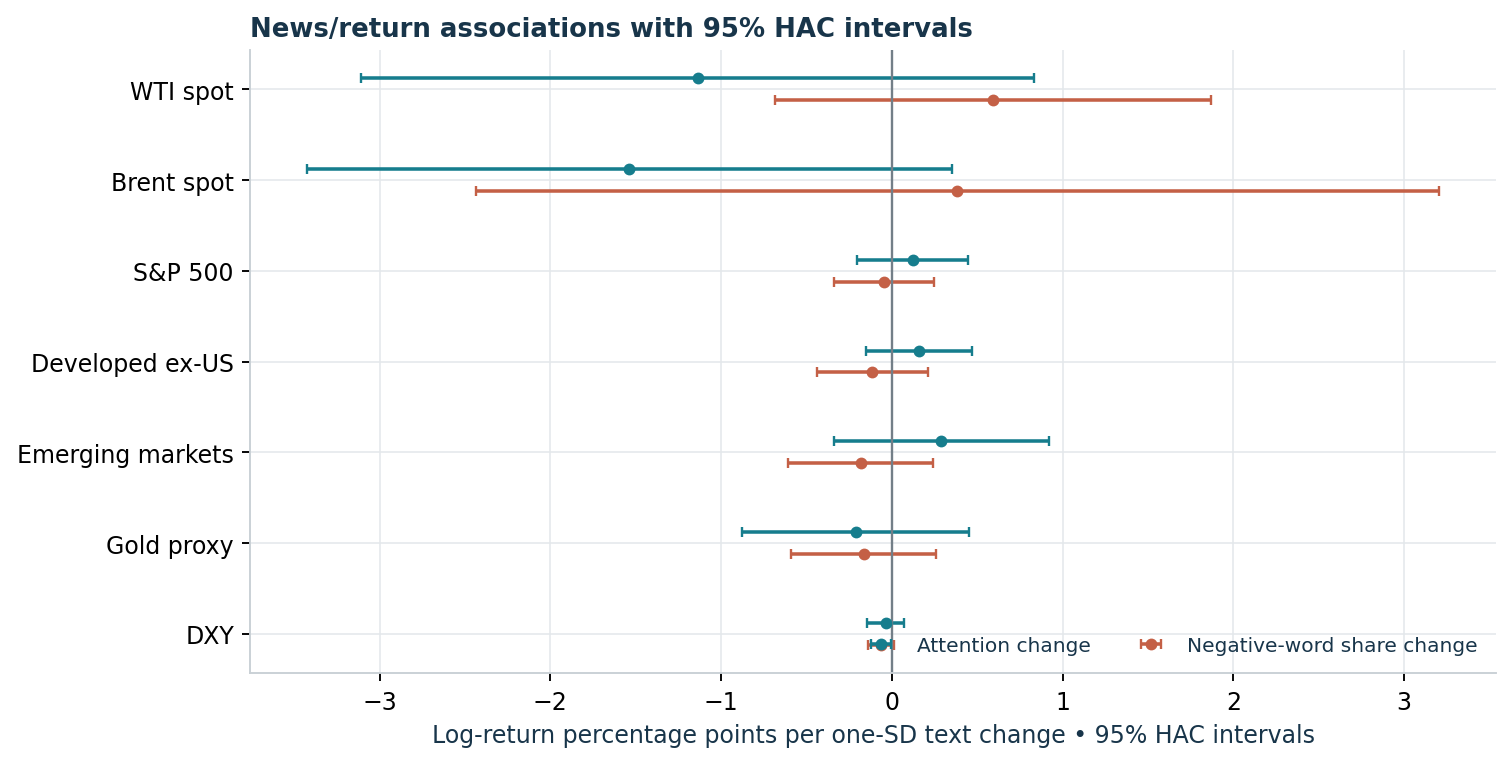

,tests,min_n,max_n,unadjusted,adjusted
version,,,,,
exclude_fomc,32,40,44,0,0
next_session,36,40,45,1,0
primary,32,41,46,0,0
publication_clock,32,40,46,2,0
uncertainty,32,41,46,1,0


In [12]:
reg = pd.read_csv(OUT/'news_regressions.csv')
display(reg[['outcome','feature','coefficient','se','ci_low','ci_high','p_value','q_value','n','feature_sd','r_squared']])
display(Image(filename=str(OUT/'figure5_regressions.png')))
versions = pd.read_csv(OUT/'news_regressions_all.csv')
display(versions.groupby('version').agg(tests=('p_value','size'),min_n=('n','min'),max_n=('n','max'),
    unadjusted=('p_value',lambda x:(x<.05).sum()),adjusted=('q_value',lambda x:(x<.05).sum())))

0 primary coefficients have unadjusted p-values below 5%; none survives adjustment (minimum q 0.758). Only 41–46 complete observations per model remain, all beginning March 3 after consecutive-session lexical and market alignment requirements. The descriptive news/market history still starts in January. Null results with this limited sample are not proof that conflict information never matters. The alternate uncertainty, publication-clock, next-session and FOMC-exclusion models are disclosed separately. These retrospective tests do not establish profitable sentiment timing.

**Investment implication.** Use text as a monitoring input, with limited conviction. The bill allocation rests on carry and low duration, not on an estimated text forecast.

## 10. Explicit investment decision
Allocate **10% of an illustrative diversified portfolio to a Treasury bill with approximately three months remaining** and retain the diversified core. This weight is an analyst risk-budget choice, not optimized or backtested. At the September 15 DGS3MO benchmark of 4.11%, approximate three-month carry is 1.0275% on the sleeve, or 0.10275 percentage points on the whole portfolio, before costs/taxes. An actual bill quote is required for implementation.

For a $100,000 illustration, a $10,000 sleeve would earn about $102.75 using that simple approximation. Assume duration 0.25 years; instantaneous price change is approximately −duration × yield change. This stress is distinct from three-month carry and is not a total-return forecast. Holding a purchased bill to maturity fixes its nominal payoff; early sale, reinvestment, inflation and opportunity cost remain risks. No trade has been placed.

In [13]:
levels = pd.read_csv(ROOT/'data/processed/market_levels.csv',index_col=0,parse_dates=True)
bill = levels.DGS3MO.dropna()
carry = bill.iloc[-1]/100*.25
stress = pd.DataFrame({'yield_shift_bp':[-100,0,100]})
stress['bill_price_effect_pct'] = -.25*stress.yield_shift_bp/100
stress['portfolio_effect_pp'] = .10*stress.bill_price_effect_pct
display(stress)
print(f'Yield benchmark {bill.index[-1].date()}: {bill.iloc[-1]:.2f}%; approximate sleeve carry {100*carry:.4f}%; portfolio {10*carry:.5f} pp.')

,yield_shift_bp,bill_price_effect_pct,portfolio_effect_pp
0,-100,0.2500,0.0250
1,0,-0.0000,-0.0000
2,100,-0.2500,-0.0250


Yield benchmark 2026-09-15: 4.11%; approximate sleeve carry 1.0275%; portfolio 0.10275 pp.


## 11. Social-media appendix: coverage and qualitative language analysis
The user includes Truth Social in the social-media scope. [Archive documentation](https://github.com/stiles/trump-truth-social-archive) identifies the updated [CNN-hosted snapshot](https://ix.cnn.io/data/truth-social/truth_archive.json). The 2026 window has 5,697 records, including 1,894 empty-text media records and 2,775 records with media. We retrieve every literal match to the stated Iran/Hormuz/etc. rule in readable text: **403 candidates**, not all Iran-related posts.

All candidate IDs, decoded texts and New York dates are checked against a separate reconstruction from the raw snapshot. This is an automated consistency audit, not independent human labels. The archive does not prove original authorship; explicit repost and attribution cues are preserved. Keyword-only relevance can occur in URLs, campaign text or multi-topic messages. Blank media posts are missing evidence, not neutral sentiment.

No verified complete 2026 X corpus was acquired; Truth Social is not called Twitter. Media, implicit references, deleted posts and unknown archive gaps prevent a complete census. The appendix describes factual subjects and qualitative linguistic context rather than numerical official/policy ratings. It does not represent public opinion or investor sentiment.

,measure,count
0,2026 archive records,5697
1,Empty readable text,1894
2,Records with media,2775
3,Text candidates,403
4,Unique candidate texts,388
5,Explicit RT cues,43
6,Explicit attribution prefixes,4
7,URL-only records,3
8,URL-only keyword matches,11
9,Candidates with unreviewed media,16


,records
Text without URL or explicit attribution prefix,258
Text plus URL,95
Explicit RT marker,43
Explicit attribution prefix,4
URL only,3


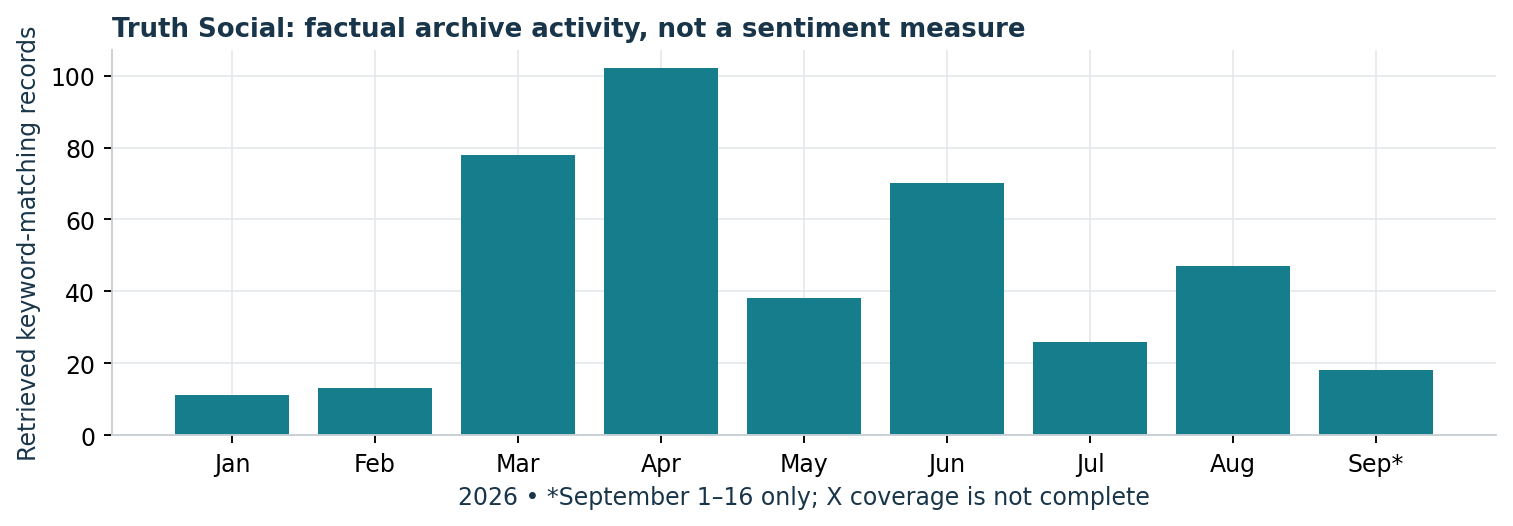

In [14]:
social_audit = json.loads((OUT/'social_audit.json').read_text())
relevance_audit = json.loads((OUT/'social_relevance_audit.json').read_text())
display(pd.DataFrame({'measure':['2026 archive records','Empty readable text','Records with media','Text candidates','Unique candidate texts',
  'Explicit RT cues','Explicit attribution prefixes','URL-only records','URL-only keyword matches','Candidates with unreviewed media'],
 'count':[social_audit['records_in_window'],social_audit['empty_text_records'],social_audit['media_records'],
          social_audit['iran_keyword_candidates'],relevance_audit['unique_candidate_texts'],
          relevance_audit['explicit_repost_marker_records'],relevance_audit['explicit_attribution_prefix_records'],
          relevance_audit['url_only_records'],relevance_audit['relevance_match_location_counts'].get('URL only',0),
          relevance_audit['records_with_unreviewed_media']]}))
display(pd.DataFrame.from_dict(relevance_audit['source_form_counts'],orient='index',columns=['records']))
display(Image(filename=str(OUT/'figure6_social.png')))
assert relevance_audit['candidate_ids_match_independent_raw_retrieval']
assert relevance_audit['all_text_and_local_dates_match_raw_snapshot']
assert not relevance_audit['sentiment_scores_or_rankings_produced']

| New York date | Source | Qualitative reading |
|---|---|---|
| 2026-01-02 | [Original post](https://truthsocial.com/@realDonaldTrump/115824439366264186) | Conditional intervention tied to treatment of protesters. Future tense and the stated condition are not evidence that intervention occurred. |
| 2026-01-12 | [Original post](https://truthsocial.com/@realDonaldTrump/115884319075881590) | Announced tariff on countries trading with Iran. Trade restrictions are a distinct channel from a physical interruption of crude supply. |
| 2026-02-04 | [Original post](https://truthsocial.com/@realDonaldTrump/116013105630663812) | Iran appears among several subjects in a conversation with China’s president. Favorable language describes the conversation and relationship, not a measured fall in war risk. |
| 2026-03-01 | [Original post](https://truthsocial.com/@realDonaldTrump/116152251973821428) | Conditional response to an anticipated Iranian action. Capitals and the conditional clause matter; keep the claimed future action separate from an observed event. |
| 2026-04-01 | [Original post](https://truthsocial.com/@realDonaldTrump/116329512466946656) | A claimed ceasefire request, a Hormuz condition and continuing-attack language share one post. A single polarity label would combine distinct propositions. |
| 2026-05-03 | [Original post](https://truthsocial.com/@realDonaldTrump/116512555123589170) | A shipping-operation announcement alongside negotiation references. The stated subjects include navigation access and conditions for shipping. |
| 2026-08-01 | [Original post](https://truthsocial.com/@realDonaldTrump/117023461141824050) | A claimed cancellation of a planned attack is linked to an agreement condition. This is not an unconditional statement that the conflict has ended. |
| 2026-09-01 | [Original post](https://truthsocial.com/@realDonaldTrump/117196950497702512) | The account reports strikes around Hormuz and states a condition for a further response. Separate the reported claim from the prospective condition. |
| 2026-09-07 | [Original post](https://truthsocial.com/@realDonaldTrump/117232304514057261) | A forecast about oil and gasoline prices depends on a future war outcome. It is an attributed price claim, not an observed price effect. |

Selected original IDs were independently matched to American Presidency Project pages; its Pacific-time display must not replace original UTC/New York dates. For example, the January 2 New York post appears on its January 1 page. This corroborates examples, not archive completeness.

Two June 11 posts first describe planned strikes and later cancellation connected to negotiations. Combining them would lose intraday sequence. Favorable language about a military operation does not imply lower physical risk. Preserve attitude holder, target, condition and attribution. Only one candidate literally names WTI; none names Brent. A price forecast in a post is not a measured Brent–WTI spread or a causal market response.

**Investment implication.** Use authenticated statements to identify claims and possible news times, verify the underlying developments independently, and avoid a trade based on a single document-level polarity label.

## 12. All seven supplied Twitter references

| Reading | Contribution used here | Important qualification |
|---|---|---|
| *Twitter sentiment analysis overview*, unattributed, 10 pp. | Explicit retrieval, cleaning and analysis stages | Historical API examples do not establish full 2026 access |
| Yener (2020), *Step by Step: Twitter Sentiment Analysis in Python*, 18 pp. | Preserve originals, deduplicate by ID, distinguish TextBlob/VADER | Preserve negation, punctuation and emphasis; word clouds are not validation |
| Bagheri & Islam (2017), *Sentiment analysis of twitter data*, 5 pp. | Short text and query choice complicate interpretation | A neutral share is not accuracy; [arXiv](https://arxiv.org/abs/1711.10377) |
| Psomakelis et al. (2014), *Comparing Methods for Twitter Sentiment Analysis*, 8 pp. | Contextual representations and supervised validation | Benchmark accuracy does not transfer automatically; [DOI](https://doi.org/10.5220/0005075302250232) |
| Carvalho & Plastino (online 2020, volume 2021), *On the evaluation and combination of state-of-the-art features in Twitter sentiment analysis*, 50 pp. | Negation, expressive features, feature/model evaluation and domain transfer | Binary benchmarks do not establish valid neutral/mixed war labels; [DOI](https://doi.org/10.1007/s10462-020-09895-6) |
| *Exploring Differences in the Sentiment Analysis Tools using Twitter Data concerning Autism Awareness*, 13 slides | Compare actual models with labels | Slide 11's TN/(FP+TN) is specificity, not precision; scikit-learn is a library |
| Stanford-derived *Sentiment Analysis*, 81 slides | Holder, target, textual unit, discourse and domain dependence | Official communication is not public sentiment; operation praise is not a war-risk measure |

No human gold-label dataset or model accuracy is invented. The local reference review keeps page/slide pointers. The financial sentiment supplement follows Loughran–McDonald rather than silently replacing it with a generic TF–IDF implementation.

## 13. Sources and limitations
[Rigobon (2003)](https://doi.org/10.1162/003465303772815727), *Identification Through Heteroskedasticity*, and [Rigobon & Sack (2003), NBER WP 9609](https://www.nber.org/papers/w9609), *The Effects of War Risk on U.S. Financial Markets*, are the supplied core sources. The supplied paper version determines historical tables; the later Federal Reserve version is not silently substituted. [Loughran–McDonald dictionary](https://sraf.nd.edu/loughranmcdonald-master-dictionary/), [GPR data](https://www.matteoiacoviello.com/gpr.htm), [Guardian Iran archive](https://www.theguardian.com/world/iran), [FOMC calendar](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm), and per-series/per-article links in the displayed metadata support the analysis.

The remaining limitations are a single news outlet; revised text and latest-vintage market data; nonexhaustive, retrospective and sometimes date-only events; nonsynchronous closes; imperfect proxies; short samples and unstable nuisance shocks; heuristic NLP without independent labels; and incomplete X/media coverage. The study neither observes calibrated war probabilities nor proves that posts cause returns. Variance shares are conditional calculations whose causal interpretation is withheld. The model checks support modest risk-taking and monitoring, not a profitable timing claim.

Code, this notebook with saved outputs, environment files, focused tests and `AI_USE.md` belong in the repository. Data, local research notes and generated CSV files remain ignored; the PDF is a separate submission file.

In [15]:
assert diagnostics['primary_news_tests'] == len(reg)
print('Primary coefficients:', len(reg), 'Adjusted p < 0.05:', diagnostics['primary_news_q_lt_05'])
print('Frozen observation cutoff:', diagnostics['cutoff'])
print('Notebook calculations completed; raw and derived data remain outside version control.')

Primary coefficients: 32 Adjusted p < 0.05: 0
Frozen observation cutoff: 2026-09-16
Notebook calculations completed; raw and derived data remain outside version control.
